# Importing Fitbit Data

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import fitbit

# gather_keys_oauth2.py file needs to be in the same directory. 
# also needs to install cherrypy: https://pypi.org/project/CherryPy/
# pip install CherryPy
import gather_keys_oauth2 as Oauth2
import pandas as pd 
import datetime


# YOU NEED TO PUT IN YOUR OWN CLIENT_ID AND CLIENT_SECRET
CLIENT_ID='23Q7KL'
CLIENT_SECRET='7f9286c713918599bb2a2e86fb73a3b5'

In [2]:
server=Oauth2.OAuth2Server(CLIENT_ID, CLIENT_SECRET)
server.browser_authorize()
ACCESS_TOKEN=str(server.fitbit.client.session.token['access_token'])
REFRESH_TOKEN=str(server.fitbit.client.session.token['refresh_token'])
auth2_client=fitbit.Fitbit(CLIENT_ID,CLIENT_SECRET,oauth2=True,access_token=ACCESS_TOKEN,refresh_token=REFRESH_TOKEN)

[15/Mar/2025:13:55:36] ENGINE Listening for SIGTERM.
[15/Mar/2025:13:55:36] ENGINE Listening for SIGHUP.
[15/Mar/2025:13:55:36] ENGINE Listening for SIGUSR1.
[15/Mar/2025:13:55:36] ENGINE Bus STARTING
CherryPy Checker:
The Application mounted at '' has an empty config.

[15/Mar/2025:13:55:36] ENGINE Started monitor thread 'Autoreloader'.
[15/Mar/2025:13:55:36] ENGINE Serving on http://127.0.0.1:8080
[15/Mar/2025:13:55:36] ENGINE Bus STARTED
gio: https://www.fitbit.com/oauth2/authorize?response_type=code&client_id=23Q7KL&redirect_uri=http%3A%2F%2F127.0.0.1%3A8080%2F&scope=activity+nutrition+heartrate+location+nutrition+profile+settings+sleep+social+weight&state=7c1WPdBfmucTLtFPeXKrlpHoDrmN8g: Operation not supported


127.0.0.1 - - [15/Mar/2025:13:55:40] "GET /?code=8b6b33fc80b093e58e2b4ae10640f7778573a9a3&state=7c1WPdBfmucTLtFPeXKrlpHoDrmN8g HTTP/1.1" 200 122 "" "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36"


[15/Mar/2025:13:55:41] ENGINE Bus STOPPING
[15/Mar/2025:13:55:42] ENGINE HTTP Server cherrypy._cpwsgi_server.CPWSGIServer(('127.0.0.1', 8080)) shut down
[15/Mar/2025:13:55:42] ENGINE Stopped thread 'Autoreloader'.
[15/Mar/2025:13:55:42] ENGINE Bus STOPPED
[15/Mar/2025:13:55:42] ENGINE Bus EXITING
[15/Mar/2025:13:55:42] ENGINE Bus EXITED
[15/Mar/2025:13:55:42] ENGINE Waiting for child threads to terminate...


In [3]:
## Function to iterate over days

def daterange(start_date, end_date):
    for n in range(int ((end_date - start_date).days)): # for loop through dates in date range
        yield start_date + datetime.timedelta(n) # return date


In [43]:
start_date = datetime.date(2025, 1, 1)
end_date = datetime.date(2025,3, 14)

In [44]:

# adjust your path depending on where you want to store your data
path='/mnt/c/Users/db24/OneDrive - Imperial College London/Desktop/FITBIT_DATA/python-fitbit-master/raw_downloaded_data'

In [45]:
def HRseries(start_date, end_date):
    dfs = []  # list to hold each day's DataFrame
    for single_date in daterange(start_date, end_date):
        date_str = single_date.strftime("%Y-%m-%d")
        # access Fitbit heart rate log and save as a DataFrame:
        fitbit_stats = auth2_client.intraday_time_series('activities/heart', base_date=date_str, detail_level='1min')
        stats = fitbit_stats['activities-heart-intraday']['dataset']
        HR = pd.DataFrame(stats)
        HR['date'] = date_str
        dfs.append(HR)
    # Concatenate all DataFrames into one
    return pd.concat(dfs, ignore_index=True)

# Example usage:
dtaframe_to_check = HRseries(start_date, end_date)
dtaframe_to_check.to_csv(path + '/HR_data.csv', index=False)


HTTPTooManyRequests: <Response [429]>

In [ ]:
# def sleep_series(start_date, end_date):
#     dfs_st = []  # list to hold each day's DataFrame
#     for single_date in daterange(start_date, end_date):
#         date_str = single_date.strftime("%Y-%m-%d")
#         # Access Fitbit sleep data using the dedicated sleep endpoint
#         sleep_stats = auth2_client.sleep(date_str)
#         # Extract sleep logs from the response (typically under the 'sleep' key)

#         SL = pd.DataFrame(sleep_stats['sleep'])
#         SL['date'] = date_str
#         dfs_st.append(SL)
#     # Concatenate all DataFrames into one after processing all dates
#     return pd.concat(dfs_st, ignore_index=True)

# # Example usage:
# sleep_df = sleep_series(start_date, end_date)
# sleep_df.to_csv(path + '/Sleep_data.csv', index=False)


In [ ]:
# def Act_steps(start_date, end_date):
#     dfs_steps = []  # list to hold each day's DataFrame
#     for single_date in daterange(start_date, end_date):
#         date_str = single_date.strftime("%Y-%m-%d")
#         # access Fitbit heart rate log and save as a DataFrame:
#         fitbit_stats_steps = auth2_client.intraday_time_series('activities/steps', base_date=date_str, detail_level='1min')
#         step_stats = fitbit_stats_steps['activities-steps-intraday']['dataset']
#         STEPS = pd.DataFrame(step_stats)
#         STEPS['date'] = date_str
#         dfs_steps.append(STEPS)
#     # Concatenate all DataFrames into one
#     return pd.concat(dfs_steps, ignore_index=True)

# # Example usage:
# dtaframe_to_check = Act_steps(start_date, end_date)
# dtaframe_to_check.to_csv(path + '/steps_data.csv', index=False)



In [42]:
## Loading file back to Python

HR_data = pd.read_csv(path + '/HR_data.csv')
Sleep_data = pd.read_csv(path + '/Sleep_data.csv')
Steps_data = pd.read_csv(path + '/Steps_data.csv')

## Working on the data_frames
HR_data['time'] = pd.to_datetime(HR_data['time']).dt.time
HR_data['date'] = pd.to_datetime(HR_data['date'])
HR_data.rename(columns={"value": "HRV"}, inplace=True)

Steps_data['time'] = pd.to_datetime(Steps_data['time']).dt.time
Steps_data['date'] = pd.to_datetime(Steps_data['date'])
Steps_data.rename(columns= {"value": "Steps"}, inplace=True)


# # ## Combinining all data into one DataFrame
temp = pd.merge(HR_data, Steps_data, on=['date', 'time'], how='outer')
temp.to_csv(path + '/temp.csv', index=False)
## How are we going to combine sleep data??


/tmp/ipykernel_41655/2732752075.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  HR_data['time'] = pd.to_datetime(HR_data['time']).dt.time
/tmp/ipykernel_41655/2732752075.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Steps_data['time'] = pd.to_datetime(Steps_data['time']).dt.time


In [46]:
temp

,time,HRV,date,Steps
0,00:00:00,57.0,2025-01-24,0
1,00:01:00,55.0,2025-01-24,0
2,00:02:00,56.0,2025-01-24,0
3,00:03:00,55.0,2025-01-24,0
4,00:04:00,57.0,2025-01-24,0
...,...,...,...,...
63355,23:55:00,70.0,2025-03-08,0
63356,23:56:00,69.0,2025-03-08,0
63357,23:57:00,65.0,2025-03-08,0
63358,23:58:00,65.0,2025-03-08,0


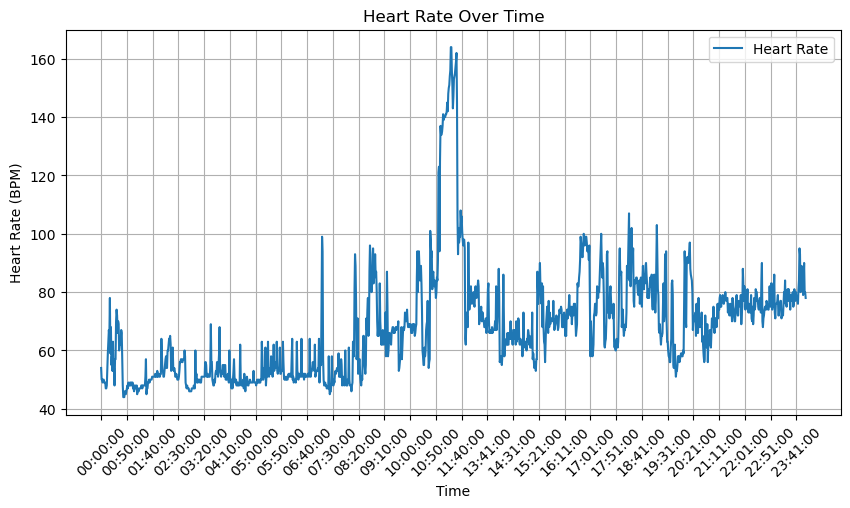

In [ ]:
# Convert 'time' to datetime (full format) but keep only the time part as a string
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.strftime("%H:%M:%S")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df["time"], df["value"], linestyle='-', label="Heart Rate")

# Formatting
plt.xlabel("Time")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Over Time")
plt.xticks(df["time"][::50], rotation=45) # Rotate x-axis for better readability
plt.legend()
plt.grid(True)

# Show plot
plt.show()
